## 1. Import Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "house_data.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
VISUAL_DIR = os.path.join(BASE_DIR, "visualizations")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("Dataset:", DATA_PATH)


Dataset: c:\Users\Aviral Maheshwari\OneDrive\Desktop\vs code avi\avi.py\House-Price-Prediction\house_data.csv


## 2. Load and Explore Dataset

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nData types:")
display(df.dtypes)
print("\nDescriptive statistics:")
display(df.describe())


Shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000



Data types:


Property_ID        str
Area             int64
Bedrooms         int64
Bathrooms        int64
Age              int64
Location           str
Property_Type      str
Price            int64
dtype: object


Descriptive statistics:


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


## 3. Data Quality and Cleaning

In [5]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().dropna().copy()

print("Cleaned shape:", df.shape)


Missing values:


Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

Duplicate rows: 0
Cleaned shape: (300, 8)


## 4. Exploratory Data Analysis

In [16]:
print("Price:")
print(f"Minimum: ₹{df.Price.min():,.2f}")
print(f"Maximum: ₹{df.Price.max():,.2f}")
print(f"Average: ₹{df.Price.mean():,.2f}")
print(f"Median : ₹{df.Price.median():,.2f}")

print("\nLocation:")
display(df["Location"].value_counts())

print("\nProperty Type:")
display(df["Property_Type"].value_counts())


Price:
Minimum: ₹3,695,000.00
Maximum: ₹58,700,000.00
Average: ₹24,883,658.33
Median : ₹22,365,000.00

Location:


Location
Suburb         105
Rural           98
City Center     97
Name: count, dtype: int64


Property Type:


Property_Type
House        107
Villa        102
Apartment     91
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=25)
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.title("House Price Distribution")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "price_distribution.png"), dpi=300)
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Area"], df["Price"], alpha=0.7)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs House Price")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "area_vs_price.png"), dpi=300)
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Bedrooms"], df["Price"], alpha=0.7)
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs House Price")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "bedrooms_vs_price.png"), dpi=300)
plt.show()


In [ ]:
counts = df["Location"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.xlabel("Location")
plt.ylabel("Properties")
plt.title("Property Distribution by Location")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "location_distribution.png"), dpi=300)
plt.show()


In [ ]:
counts = df["Property_Type"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.xlabel("Property Type")
plt.ylabel("Properties")
plt.title("Property Distribution by Type")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "property_type_distribution.png"), dpi=300)
plt.show()


In [ ]:
numeric_cols = ["Area", "Bedrooms", "Bathrooms", "Age", "Price"]
corr = df[numeric_cols].corr()
display(corr)
display(corr["Price"].sort_values(ascending=False))

plt.figure(figsize=(7,6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=30)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "correlation_heatmap.png"), dpi=300)
plt.show()


## 5. Feature Selection and Train-Test Split

In [7]:
X = df[["Area", "Bedrooms", "Bathrooms", "Age", "Location", "Property_Type"]]
y = df["Price"]

numeric_features = ["Area", "Bedrooms", "Bathrooms", "Age"]
categorical_features = ["Location", "Property_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 240
Testing samples : 60


## 6. Categorical Encoding

In [8]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
feature_names = [x.replace("num__", "").replace("cat__", "") for x in feature_names]

print("Processed shape:", X_train_processed.shape)
print("Features:", feature_names)


Processed shape: (240, 10)
Features: ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location_City Center', 'Location_Rural', 'Location_Suburb', 'Property_Type_Apartment', 'Property_Type_House', 'Property_Type_Villa']


## 7. Linear Regression From Scratch

Normal Equation:

`β = (XᵀX)⁻¹Xᵀy`


In [9]:
Xtr = np.column_stack([np.ones(len(X_train_processed)), X_train_processed])
Xte = np.column_stack([np.ones(len(X_test_processed)), X_test_processed])

beta = np.linalg.pinv(Xtr) @ y_train.to_numpy()
pred_scratch = Xte @ beta

mae_scratch = mean_absolute_error(y_test, pred_scratch)
mse_scratch = mean_squared_error(y_test, pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch = r2_score(y_test, pred_scratch)

print(f"MAE : ₹{mae_scratch:,.2f}")
print(f"MSE : {mse_scratch:,.2f}")
print(f"RMSE: ₹{rmse_scratch:,.2f}")
print(f"R²  : {r2_scratch:.4f}")

pd.DataFrame({"Feature": ["Intercept"] + feature_names, "Coefficient": beta}).to_csv(
    os.path.join(OUTPUT_DIR, "linear_regression_coefficients.csv"), index=False
)


MAE : ₹2,188,736.34
MSE : 8,454,330,868,276.73
RMSE: ₹2,907,633.21
R²  : 0.9406


## 8. Scikit-learn Linear Regression

In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
pred_linear = linear_model.predict(X_test_processed)

mae_linear = mean_absolute_error(y_test, pred_linear)
mse_linear = mean_squared_error(y_test, pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, pred_linear)

print(f"MAE : ₹{mae_linear:,.2f}")
print(f"MSE : {mse_linear:,.2f}")
print(f"RMSE: ₹{rmse_linear:,.2f}")
print(f"R²  : {r2_linear:.4f}")

display(pd.DataFrame({"Feature": feature_names, "Coefficient": linear_model.coef_}))


MAE : ₹2,188,736.34
MSE : 8,454,330,868,276.58
RMSE: ₹2,907,633.21
R²  : 0.9406


,Feature,Coefficient
0,Area,7.558956e+03
1,Bedrooms,1.585709e+06
2,Bathrooms,4.545940e+05
3,Age,-8.244368e+04
4,Location_City Center,8.453714e+06
5,Location_Rural,-8.274417e+06
6,Location_Suburb,-1.792977e+05
7,Property_Type_Apartment,1.813929e+05
8,Property_Type_House,-4.265108e+05
9,Property_Type_Villa,2.451179e+05


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, pred_linear, alpha=0.7)
lo, hi = min(y_test.min(), pred_linear.min()), max(y_test.max(), pred_linear.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression - Actual vs Predicted")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "sklearn_actual_vs_predicted.png"), dpi=300)
plt.show()


## 9. Polynomial Regression

In [11]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train_processed, y_train)
pred_poly = poly_model.predict(X_test_processed)

mae_poly = mean_absolute_error(y_test, pred_poly)
mse_poly = mean_squared_error(y_test, pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, pred_poly)

print(f"MAE : ₹{mae_poly:,.2f}")
print(f"MSE : {mse_poly:,.2f}")
print(f"RMSE: ₹{rmse_poly:,.2f}")
print(f"R²  : {r2_poly:.4f}")

print("\nObservation: If this synthetic dataset produces an unusually high or perfect score, report it as an observed result and interpret it cautiously rather than assuming real-world performance will be perfect.")


MAE : ₹0.00
MSE : 0.00
RMSE: ₹0.00
R²  : 1.0000

Observation: If this synthetic dataset produces an unusually high or perfect score, report it as an observed result and interpret it cautiously rather than assuming real-world performance will be perfect.


## 10. Decision Tree Regression

In [12]:
tree_model = DecisionTreeRegressor(
    max_depth=6, min_samples_split=5, min_samples_leaf=2, random_state=42
)
tree_model.fit(X_train_processed, y_train)
pred_tree = tree_model.predict(X_test_processed)

mae_tree = mean_absolute_error(y_test, pred_tree)
mse_tree = mean_squared_error(y_test, pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, pred_tree)

print(f"MAE : ₹{mae_tree:,.2f}")
print(f"MSE : {mse_tree:,.2f}")
print(f"RMSE: ₹{rmse_tree:,.2f}")
print(f"R²  : {r2_tree:.4f}")


MAE : ₹2,348,854.24
MSE : 8,843,197,182,745.06
RMSE: ₹2,973,751.37
R²  : 0.9379


## 11. Random Forest Regression

In [13]:
forest_model = RandomForestRegressor(
    n_estimators=200, max_depth=8, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
forest_model.fit(X_train_processed, y_train)
pred_forest = forest_model.predict(X_test_processed)

mae_forest = mean_absolute_error(y_test, pred_forest)
mse_forest = mean_squared_error(y_test, pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, pred_forest)

print(f"MAE : ₹{mae_forest:,.2f}")
print(f"MSE : {mse_forest:,.2f}")
print(f"RMSE: ₹{rmse_forest:,.2f}")
print(f"R²  : {r2_forest:.4f}")


MAE : ₹1,643,060.78
MSE : 4,843,684,174,383.45
RMSE: ₹2,200,837.15
R²  : 0.9660


In [ ]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

importance.to_csv(
    os.path.join(OUTPUT_DIR, "random_forest_feature_importance.csv"),
    index=False
)

plt.figure(figsize=(9,6))
top = importance.head(10).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "random_forest_feature_importance.png"), dpi=300)
plt.show()


## 12. Model Comparison

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression From Scratch",
        "Scikit-Learn Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [mae_scratch, mae_linear, mae_poly, mae_tree, mae_forest],
    "MSE": [mse_scratch, mse_linear, mse_poly, mse_tree, mse_forest],
    "RMSE": [rmse_scratch, rmse_linear, rmse_poly, rmse_tree, rmse_forest],
    "R2_Score": [r2_scratch, r2_linear, r2_poly, r2_tree, r2_forest]
})

display(comparison.round(4))
comparison.to_csv(os.path.join(OUTPUT_DIR, "complete_model_comparison.csv"), index=False)


,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression From Scratch,2.188736e+06,8.454331e+12,2.907633e+06,0.9406
1,Scikit-Learn Linear Regression,2.188736e+06,8.454331e+12,2.907633e+06,0.9406
2,Polynomial Regression,3.000000e-04,0.000000e+00,4.000000e-04,1.0000
3,Decision Tree,2.348854e+06,8.843197e+12,2.973751e+06,0.9379
4,Random Forest,1.643061e+06,4.843684e+12,2.200837e+06,0.9660


In [ ]:
plt.figure(figsize=(10,6))
plt.bar(comparison["Model"], comparison["R2_Score"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model R² Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "all_models_r2_comparison.png"), dpi=300)
plt.show()

plt.figure(figsize=(10,6))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model RMSE Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_DIR, "all_models_rmse_comparison.png"), dpi=300)
plt.show()


## 13. Best Model and Predictions vs Actual

,Actual_Price,Predicted_Price,Absolute_Error
0,8930000,8.930000e+06,0.000232
1,18085000,1.808500e+07,0.000031
2,53980000,5.398000e+07,0.000650
3,24800000,2.480000e+07,0.000386
4,21615000,2.161500e+07,0.000293
5,31850000,3.185000e+07,0.000306
6,18850000,1.885000e+07,0.000354
7,41170000,4.117000e+07,0.000096
8,24790000,2.479000e+07,0.000520
9,30172500,3.017250e+07,0.000085


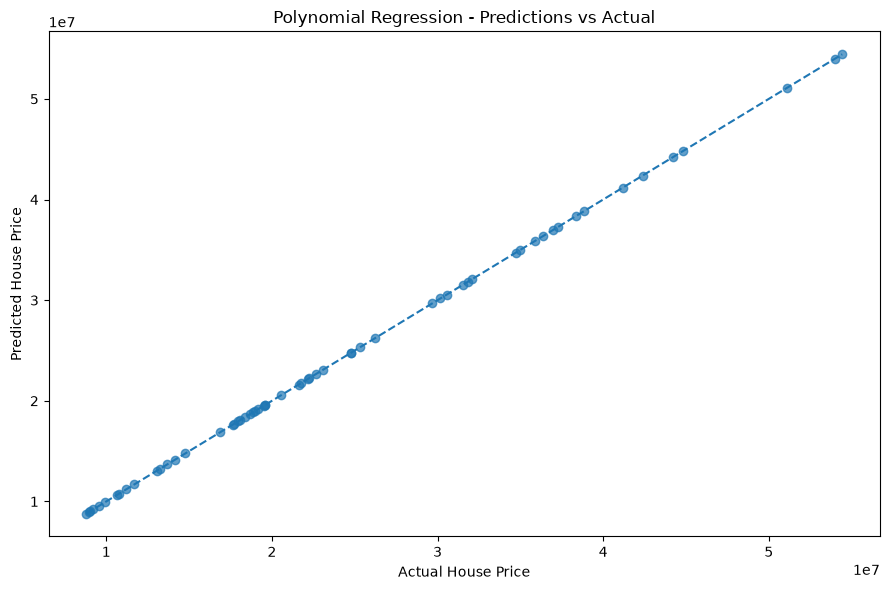

Best model: Polynomial Regression
R²: 1.0000
MAE: ₹0.00
RMSE: ₹0.00


In [15]:
best = comparison.loc[comparison["R2_Score"].idxmax()]
predictions = {
    "Linear Regression From Scratch": pred_scratch,
    "Scikit-Learn Linear Regression": pred_linear,
    "Polynomial Regression": pred_poly,
    "Decision Tree": pred_tree,
    "Random Forest": pred_forest
}

best_predictions = predictions[best["Model"]]

final_predictions = pd.DataFrame({
    "Actual_Price": y_test.to_numpy(),
    "Predicted_Price": best_predictions
})
final_predictions["Absolute_Error"] = (
    final_predictions["Actual_Price"] - final_predictions["Predicted_Price"]
).abs()

display(final_predictions.head(10))

final_predictions.to_csv(
    os.path.join(OUTPUT_DIR, "final_model_predictions.csv"), index=False
)

plt.figure(figsize=(9,6))
plt.scatter(final_predictions["Actual_Price"], final_predictions["Predicted_Price"], alpha=0.7)
lo = min(final_predictions["Actual_Price"].min(), final_predictions["Predicted_Price"].min())
hi = max(final_predictions["Actual_Price"].max(), final_predictions["Predicted_Price"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"{best['Model']} - Predictions vs Actual")
plt.tight_layout()

# Required submission filename
plt.savefig(os.path.join(BASE_DIR, "predictions_vs_actual.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(VISUAL_DIR, "best_model_actual_vs_predicted.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Best model:", best["Model"])
print(f"R²: {best['R2_Score']:.4f}")
print(f"MAE: ₹{best['MAE']:,.2f}")
print(f"RMSE: ₹{best['RMSE']:,.2f}")
